In [ ]:
import os
import shutil
import pandas as pd

kaggle_csv_path = r'C:\Users\HP\Downloads\cassava-leaf-disease-classification\train.csv'
kaggle_images_path = r'C:\Users\HP\Downloads\cassava-leaf-disease-classification\train_images'


project_train_dir = '../data/train'

#rrad csv
print("Reading CSV...")
df = pd.read_csv(kaggle_csv_path)

# the disease names mapping
class_names = {
    0: "Cassava Bacterial Blight",
    1: "Cassava Brown Streak",
    2: "Cassava Green Mottle",
    3: "Cassava Mosaic",
    4: "Healthy"
}

# Creating sub foldes forproject
print("Creating subfolders...")
for label, name in class_names.items():
    os.makedirs(os.path.join(project_train_dir, name), exist_ok=True)

# copying 100 images per class to my project folder for fast testing
samples_per_class = 100

print(f"Copying {samples_per_class} images per class. This might take a minute...")
for label in class_names.keys():
    # gettng subset of images for this label
    subset = df[df['label'] == label].head(samples_per_class)
    
    for _, row in subset.iterrows():
        #CSV file has a column named 'image_id'
        src = os.path.join(kaggle_images_path, row['image_id'])
        dst = os.path.join(project_train_dir, class_names[label], row['image_id'])
        
        if os.path.exists(src):
            shutil.copy(src, dst)

print("Data successfully sampled and organized into your project folders!")

Reading CSV...
Creating subfolders...
Copying 100 images per class. This might take a minute...
Data successfully sampled and organized into your project folders!


In [5]:
!pip install opencv-python-headless matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Generating visualizations...


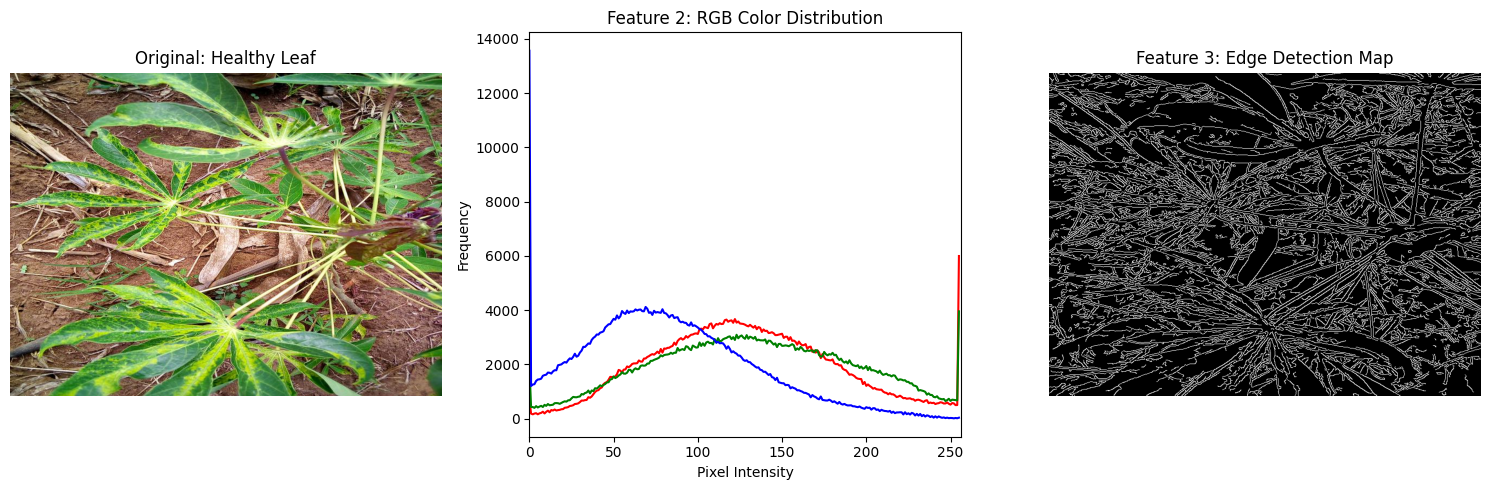

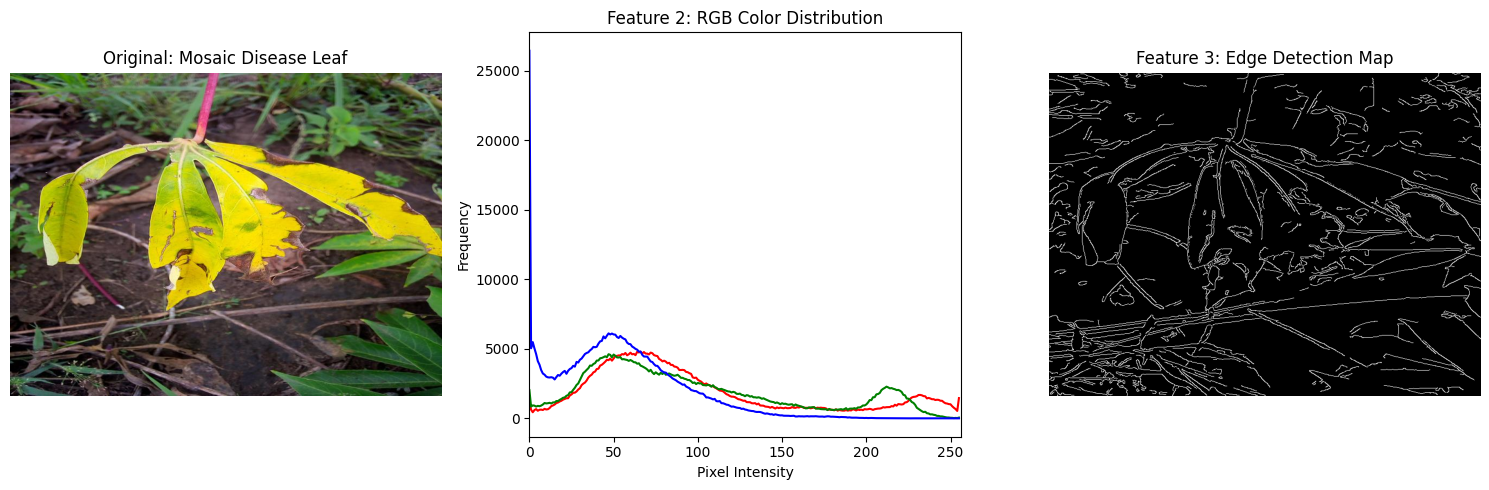

In [2]:
import cv2
import matplotlib.pyplot as plt
import glob
import os

# Define the paths to your newly organized data
project_train_dir = '../data/train'

# Grab the first image from the Healthy and Mosaic Disease folders
healthy_images = glob.glob(os.path.join(project_train_dir, 'Cassava Mosaic', '*.jpg'))
diseased_images = glob.glob(os.path.join(project_train_dir, 'Healthy', '*.jpg' ))

# Ensure we found images before proceeding
if not healthy_images or not diseased_images:
    print("Error: Could not find images. Check if the folders contain .jpg files.")
else:
    healthy_img_path = healthy_images[0]
    diseased_img_path = diseased_images[0]

    def visualize_features(img_path, title):
        # 1. Load image (OpenCV loads as BGR, so we convert to RGB for plotting)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 2. Feature: Edge Detection (Canny)
        # We blur it slightly first to remove minor background noise
        blurred = cv2.GaussianBlur(img, (5, 5), 0)
        edges = cv2.Canny(blurred, 100, 200)

        # --- Plotting ---
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot 1: Original Image
        axes[0].imshow(img_rgb)
        axes[0].set_title(f'Original: {title}')
        axes[0].axis('off')
        
        # Plot 2: RGB Histogram (Color Feature)
        colors = ('r', 'g', 'b')
        for i, color in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
            axes[1].plot(hist, color=color)
            axes[1].set_xlim([0, 256])
        axes[1].set_title('Feature 2: RGB Color Distribution')
        axes[1].set_xlabel('Pixel Intensity')
        axes[1].set_ylabel('Frequency')
        
        # Plot 3: Edge Map (Texture Feature)
        axes[2].imshow(edges, cmap='gray')
        axes[2].set_title('Feature 3: Edge Detection Map')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

    # Run the visualizer for both images
    print("Generating visualizations...")
    visualize_features(healthy_img_path, "Healthy Leaf")
    visualize_features(diseased_img_path, "Mosaic Disease Leaf")